# EDA

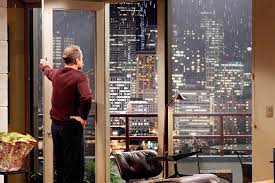

In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


#warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

df_original = pd.read_csv("data/eda.csv")
df = df_original.copy()

In [70]:
# First check for data types and missing values
df.info()
row_count = df.shape[0]
print(f"Total rows= {row_count}")

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

# Cleaning data:
Since using modulo operator on floats can be deceiving we use a different alghorithm to check if floats adhere to certain stepsizes:

`scaled = df[<column>] * 1/<stepsize>`

`do_not_adhere = ~np.isclose(scaled, scaled.round())`


In [154]:
# Meaning of Icons:
# - All good: ✅ 
# - Correction helpful: ⚠️ 
# - Decision or Correction needed: ❌


# column names: 
# - lower case ✅
# - underscores✅


# id: 
# - integer ✅
# - no missing ✅


# bedrooms: 
# - float but only whole values ⚠️
# - non missing ✅
not_integer = ~np.isclose(df["bedrooms"], df["bedrooms"].round())
print(f"Bedrooms other than whole value: {not_integer.sum()}") # == 0

# - switch to integer
df["bedrooms"] = df["bedrooms"].round().astype(int)


# bathrooms: 
# - float and only quarter steps are allowed ✅
# - none missing ✅
scaled = df["bathrooms"] * 4
not_quarter_step = ~np.isclose(scaled, scaled.round())
print(f"Bathrooms other than quarter steps: {not_quarter_step.sum()}")


# sqft_living:
# - float but only whole values ⚠️
# - none missing ✅

# - switch to integer
df["sqft_living"] = df["sqft_living"].round().astype(int)

# sqft_lot:
# - float but only whole values ⚠️
# - none missing ✅

# - switch to integer
df["sqft_lot"] = df["sqft_lot"].round().astype(int)

Bedrooms other than whole value: 0
Bathrooms other than quarter steps: 0


In [ ]:
# floors:
# - float and non missing ✅
# - stepsize of 0.5 ✅
scaled = df["floors"] * 2
not_half_step = ~np.isclose(scaled, scaled.round())
print(f"Floors other than half steps: {not_half_step.sum()}")

Floors other than half steps: 0


In [ ]:
# waterfront
# - should be boolean or category (yes/no) ❌
# - missing values ❌
# Check different values
df["waterfront"].value_counts()

# Values 0 or 1 (and NaN)
# Since where a waterfront is available it is a major selling point
# we assume that only where there is no waterfront available one would exlude this info
# => NaN to 0
df["waterfront"] = df["waterfront"].fillna(0)

# the proportions haven't changed much also
print(f"Proportions before: {df_original['waterfront'].value_counts(normalize=True)}")
print(f"Proportions after: {df['waterfront'].value_counts(normalize=True)}")

#switch from numeric to boolean to be more precise
df["waterfront"] = df["waterfront"].astype(bool)

Proportions before: waterfront
0.000   0.992
1.000   0.008
Name: proportion, dtype: float64
Proportions after: waterfront
0.000   0.993
1.000   0.007
Name: proportion, dtype: float64


In [ ]:
# view
# - missing values ❌
# - float instead of category or integers ⚠️

# We keep the rows with the missing view for now since they are just a few
# But switch to nullable integer to be more precise
df["view"] = df["view"].astype("Int64")


In [155]:
# condition
# - Values are integer and in correct range ✅
# - no missing values ✅

df.condition.value_counts()
df.condition.isna().sum()

np.int64(0)

In [ ]:
# grade
# - Values are integer and in correct range ✅
# - no missing values ✅

df.grade.value_counts()
df.grade.isna().sum()

np.int64(0)

In [157]:
# sqft_above
# - float but only whole values ⚠️
# - none missing ✅
df.sqft_above.isna().sum()

df["sqft_above"] = df["sqft_above"].round().astype(int)

In [160]:
# sqft_basement
# - float but only whole values ⚠️
# - missing values ❌

# Validate assumption: sqft_living = sqft_above  + sqft_basement

# Get needed data where sqft_basement is not Nan. 
# The others we know already are complete
sqrf_data = df[["sqft_living", "sqft_above", "sqft_basement"]][~df["sqft_basement"].isna()]

# From that, get only the rows that follow our assumption
sqrf_data_valid = sqrf_data.query("sqft_above + sqft_basement == sqft_living")

# Check our assumption
print(f"Our assumtpion is {sqrf_data.equals(sqrf_data_valid)}") # == True

#check all whole values
not_integer = ~np.isclose(sqrf_data["sqft_basement"], sqrf_data["sqft_basement"].round())
print(f"sqrf_data other than whole value: {not_integer.sum()}") # == 0

Our assumtpion is True
sqrf_data other than whole value: 0


In [ ]:
# sqft_basement
# Replace NaN with "sqft_living - sqft_above"
# Easy way, do it for every row, even where sqft_basement was already set
# We proved already that this will not change any existing data
df["sqft_basement"] = df["sqft_living"] - df["sqft_above"]

# dtype will also be int64 now since we set sqft_living and sqft_above to int64 earlier

<class 'pandas.Series'>
RangeIndex: 21597 entries, 0 to 21596
Series name: sqft_basement
Non-Null Count  Dtype
--------------  -----
21597 non-null  int64
dtypes: int64(1)
memory usage: 168.9 KB


In [ ]:
# yr_built

df["yr_built"].info()

<class 'pandas.Series'>
RangeIndex: 21597 entries, 0 to 21596
Series name: yr_built
Non-Null Count  Dtype
--------------  -----
21597 non-null  int64
dtypes: int64(1)
memory usage: 168.9 KB


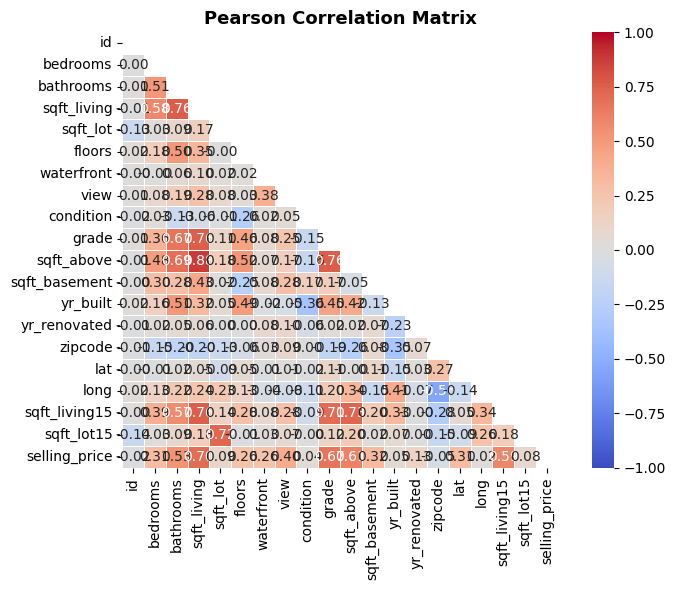

In [74]:
import seaborn as sns
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr(method="pearson").round(2)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


# Step 3: Plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,  # show the number in each cell
    fmt=".2f",
    cmap="coolwarm",  # red = positive, blue = negative correlation
    vmin=-1,
    vmax=1,  # fix the colour scale
    square=True,
    linewidths=0.5,
    ax=ax,
)

ax.set_title(
    "Pearson Correlation Matrix",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  int64  
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     21597 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21